## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## DataSet Import

In [ ]:
df = pd.read_csv ("../data/raw/raw_data.csv", sep=';')
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7726 entries, 0 to 7725
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   WO                                     7726 non-null   int64  
 1   FASE                                   7726 non-null   int64  
 2   ARTICOLO                               7719 non-null   float64
 3   Descrizione Articolo                   7719 non-null   str    
 4   ID DAD                                 7726 non-null   int64  
 5   C.d.L. Prev                            7719 non-null   float64
 6   Descrizione Centro di Lavoro previsto  7719 non-null   str    
 7   C.d.L. Effett                          7619 non-null   float64
 8   Cod CIC                                7720 non-null   str    
 9   Descrizione Macchina                   7720 non-null   str    
 10  Data fine                              7726 non-null   str    
 11  Ora fine       

WO                                         0
FASE                                       0
ARTICOLO                                   7
Descrizione Articolo                       7
ID DAD                                     0
C.d.L. Prev                                7
Descrizione Centro di Lavoro previsto      7
C.d.L. Effett                            107
Cod CIC                                    6
Descrizione Macchina                       6
Data fine                                  0
Ora fine                                   0
Scarti Materiale                           0
Scarti Lavoraz.                            0
Pezzi Ripassati                            0
Pezzi da Avanzare                          0
Pezzi Mancanti                             0
Tot pezzi Contegg.                         0
Qta totale su AS/400                       0
Qta opera su AS/400                        0
Tempo Attrezz. ORE                         0
Tempo Lavoraz. ORE                         0
Durata Sos

## Data Cleaning

In [3]:
# converting data format from ita to eng
# union of colums 'Data fine' 'Ora fine' into one column
df["Data_Ora_Fine"] = pd.to_datetime(df["Data fine"] + " " + df["Ora fine"], format="%d/%m/%Y %H:%M:%S")
df = df.drop(["Data fine", "Ora fine"], axis=1)

# conversion str to int
df["Tempo Attrezz. ORE"] = (
    df["Tempo Attrezz. ORE"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)
df["Tempo Lavoraz. ORE"] = (
    df["Tempo Lavoraz. ORE"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)
df["Durata Soste Ore"] = (
    df["Durata Soste Ore"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)
df["Buon Tempo Ciclo MIN."] = (
    df["Buon Tempo Ciclo MIN."]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)
df["Tempo Macc AS400 ORE"] = (
    df["Tempo Macc AS400 ORE"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)
df["Tempo Attr AS400 ORE"] = (
    df["Tempo Attr AS400 ORE"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)

# Convert min to h
df["Buon Tempo Ciclo MIN."] = df["Buon Tempo Ciclo MIN."] / 60
df.rename(columns={"Buon Tempo Ciclo MIN.": "Buon Tempo Ciclo ORE"}, inplace=True)

# remove useless rows
df = df[df["Tot pezzi Contegg."] > 0]
df = df[df["Tempo Lavoraz. ORE"] > 0]

# since they're not much drop the rows that contain null values
df = df.dropna()

# creating new variables
df["Tempo_Teorico_TOT_ORE"] = df["Buon Tempo Ciclo ORE"] * df["Tot pezzi Contegg."]
df["Indice_Inefficienza"] = df["Tempo Lavoraz. ORE"] / df["Tempo_Teorico_TOT_ORE"]
df = df[df["Tempo_Teorico_TOT_ORE"] > 0]

# Range Interquartile (IQR)
Q1 = df["Indice_Inefficienza"].quantile(0.25)
Q3 = df["Indice_Inefficienza"].quantile(0.75)
IQR = Q3 - Q1

# upperbound calculation to discard values
upper_bound = Q3 + 1.5 * IQR
df = df[df["Indice_Inefficienza"] < upper_bound]

# lowerbound calculation to discard values
lower_bound = Q1 - 1.5 * IQR
df = df[df["Indice_Inefficienza"] > lower_bound]

# creating csv file of clean datas
df.to_csv("../data/processed/clean_data.csv", index=False)

df = df.sort_values("Data_Ora_Fine")

# ****** APPUNTI ******
# primo dato pulito 2025-01-07 09:33:46 ultimo dato pulito 2026-02-24 11:13:01 
# appunti tesi:
# impostando un valore arbitrario come 10 in df = df[df["Indice_Inefficienza"] < 10]
# si ottenevano degli errori nei dati in quanto si ha una media = 1.33 e una 
# deviazione standard = 0.48
# ovvero in media le macchine ci mettono il 33% in più rispetto al tempo teorico
# e c'è un alta variabilità tra il tempo di produzione delle macchine (0.48)
# con una variabilità del (0.48 / 1.33) × 100 = 36% rispetto al valore medio
# 1 deviazione standard → 1.33 + 0.48 = 1.81
# 2 deviazioni → 1.33 + (2 × 0.48) = 2.29
# 3 deviazioni → 1.33 + (3 × 0.48) = 2.77
# dunque:
# > 1.8	inefficienza anomala leggera
# > 2.3	inefficienza forte
# > 2.8	quasi sicuramente errore o caso eccezionale
# dove il valore più alto era di 8.07 che è chiaramente un errore o un caso speciale
# in quanto significherebbe che una macchina ci ha impegato 8 volte tanto rispetto al tempo teorico
# dunque ho calcolato il valore sul quale basarsi per scartare i dati speciali o di errore
# con il metodo dei quartili in questo modo si ha un valore massimo di 2.5
# --------------------------------------------------------------------------------------------------
# quantita di wo che non hanno un benchmark di tempo ovvero quanto ci si aspetta che
# la macchina ci impieghi a produrre il wo (nel gestionale)
# df[df["Tempo Macc AS400 ORE"] == 0].shape[0] / len(df)
# risultato: 0.17410643367752185 il 17% dei wo nei dati puliti hanno benchmark 0.0

## Graphs

In [ ]:
df = pd.read_csv("../data/processed/clean_data.csv")
sns.set_theme(style="whitegrid", palette="muted")

## Histogram of the Global Inefficiency Index

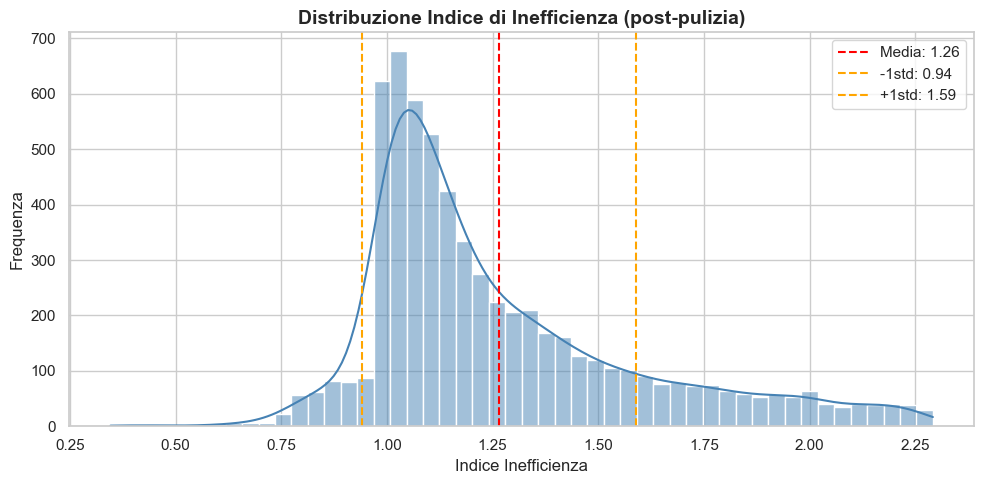

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["Indice_Inefficienza"], bins=50, kde=True, color="steelblue", ax=ax)

media = df["Indice_Inefficienza"].mean()
std = df["Indice_Inefficienza"].std()

ax.set_title("Distribuzione Indice di Inefficienza (post-pulizia)", fontsize=14, fontweight="bold")
ax.set_xlabel("Indice Inefficienza")
ax.set_ylabel("Frequenza")
ax.axvline(media, color="red", linestyle="--", label=f"Media: {df['Indice_Inefficienza'].mean():.2f}")
ax.axvline(media - std, color="orange", linestyle="--", linewidth=1.5, label=f"-1std: {media-std:.2f}")
ax.axvline(media + std, color="orange", linestyle="--", linewidth=1.5, label=f"+1std: {media+std:.2f}")
ax.legend()
plt.tight_layout()
plt.show()

# ****** APPUNTI ******
# La distribuzione è pulita, senza outlier patologici. 
# La curva KDE sovrapposta mostra la forma reale. 
# La linea rossa indica la media. Le line arancioni la media +/- la std
# Il cleaning IQR ha funzionato.

## Boxplot for machine

C:\Users\filge\AppData\Local\Temp\ipykernel_6372\418955631.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


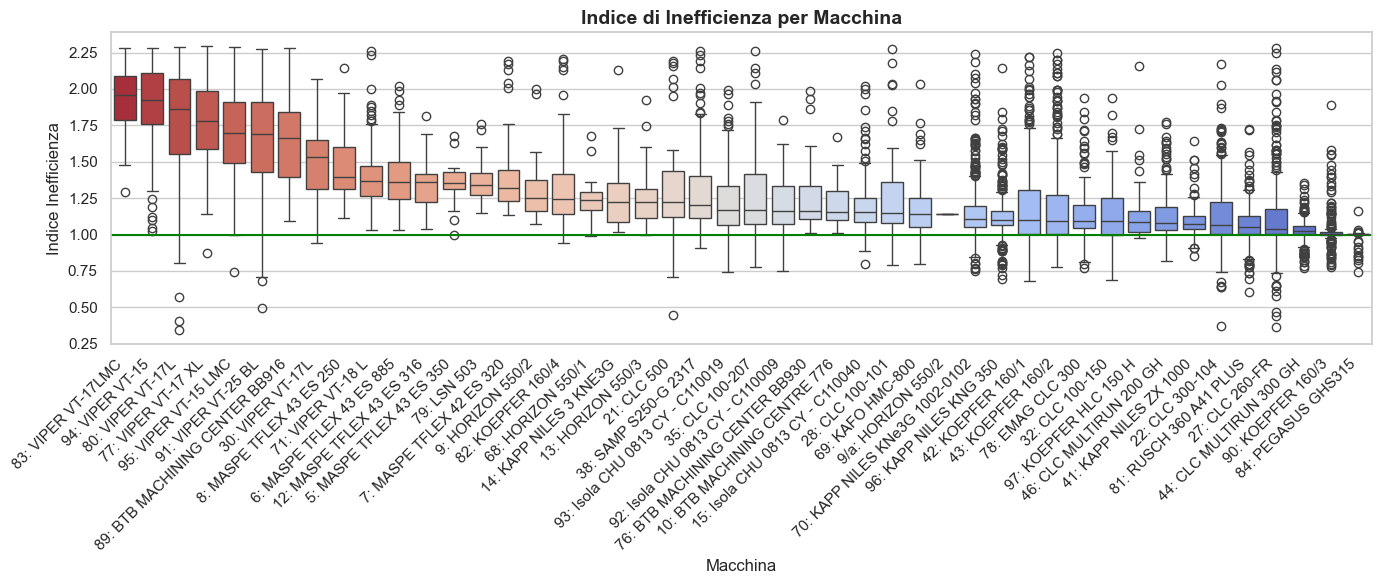

In [ ]:
# boxplot displaying machines from the least effiecient to the most efficient 
order = (
    df.groupby("Descrizione Macchina")["Indice_Inefficienza"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="Descrizione Macchina",
    y="Indice_Inefficienza",
    order=order,
    palette="coolwarm_r",
    ax=ax
)
ax.axhline(y=1.0, color="green", linestyle="-", label="Tempo teorico (1.00)")
ax.set_title("Indice di Inefficienza per Macchina", fontsize=14, fontweight="bold")
ax.set_xlabel("Macchina")
ax.set_ylabel("Indice Inefficienza")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ****** APPUNTI ******
# Quali macchine hanno mediana alta (inefficienti in media) 
# e quali hanno box largo (instabili/variabili).
# Utile per scegliere la macchina target del modello ML.
# Ordina per mediana decrescente

## Number of observations per machine

C:\Users\filge\AppData\Local\Temp\ipykernel_6372\234000800.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


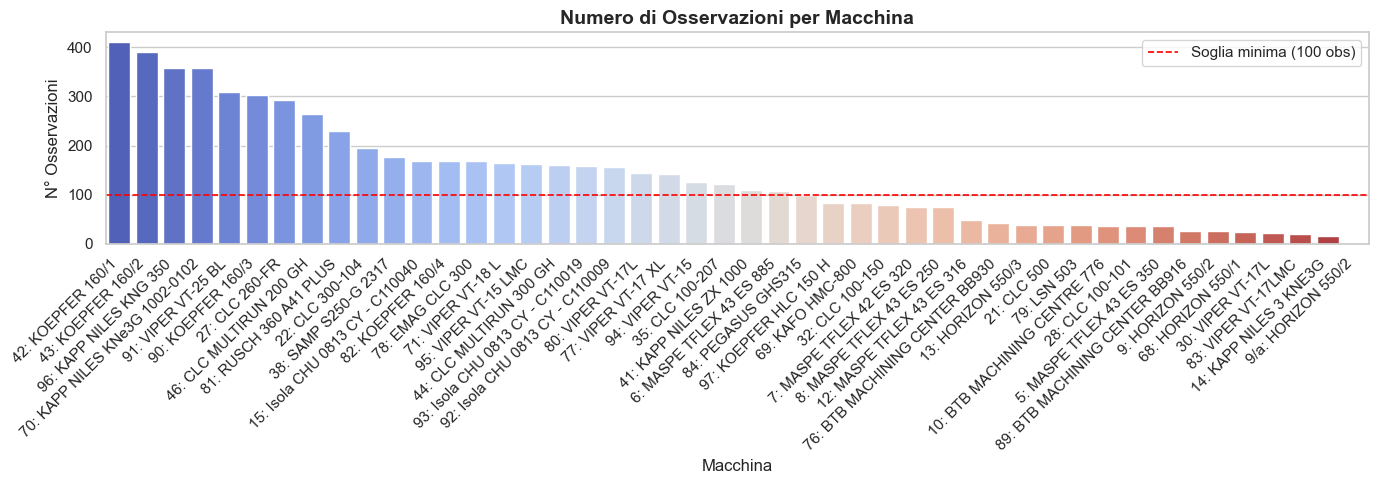

In [ ]:
# number of observatione per machine that help you choose wich machine to study for ML
obs_per_machine = (
    df.groupby("Descrizione Macchina")
    .size()
    .reset_index(name="N_Osservazioni")
    .sort_values("N_Osservazioni", ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 5))

bars = sns.barplot(
    data=obs_per_machine,
    x="Descrizione Macchina",
    y="N_Osservazioni",
    palette="coolwarm",
    ax=ax
)

ax.axhline(100, color="red", linestyle="--", linewidth=1.2, label="Soglia minima (100 obs)")
ax.set_title("Numero di Osservazioni per Macchina", fontsize=14, fontweight="bold")
ax.set_xlabel("Macchina")
ax.set_ylabel("N° Osservazioni")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

# ****** APPUNTI ******
# Quante osservazioni ha ogni macchina. 
# La linea rossa evidenzia la soglia minima per cui un modello ML è statisticamente affidabile. 
# Macchine sotto soglia vanno escluse.

## Machine Choice

In [ ]:
# choosing the machine based on his data
df.groupby("Descrizione Macchina").agg(
    count=("Indice_Inefficienza", "count"),
    mean=("Indice_Inefficienza", "mean"),
    std=("Indice_Inefficienza", "std"),
    perc_over_1_5=("Indice_Inefficienza", lambda x: (x > 1.5).mean()),
    perc_over_1_8=("Indice_Inefficienza", lambda x: (x > 1.8).mean())
).sort_values(by="count", ascending=False)

# ****** APPUNTI ******
# raggruppo le macchine in base alle osservazioni, media, std, la percentuale di wo al di sopra di 1.5 e 1.8 
# considerando le macchine che hanno almeno 300 obs osserviamo che ad esempio la macchin viper vt-25 bl
# ha una media di 1.65 dove il 68% è sopra 1.5 e il 36% sopra 1.8 dunque non è una macchina che ha dei 
# comportamenti anomali ma semplicemente è sempre inefficiente
# al contrario una macchina come la KOEPFER 160/3 ha una media di 1.02 e una std molto bassa di 0.11
# dove l'1% è sopra 1.5 e lo 0,3% sopra 1.8 per cui anch'essa 
# non ha comportamenti anomali ma è sempre efficiente.
# le macchine più interessanti e con più obs sono:
# - KOEPFER 160/1 
#   con 410 obs, media di 1.17, l'std di 0.26, dove l'11% è sopra 1.5, il 3.9% sopra 1.8   
# - KOEPFER 160/2
#   con 390 obs, media di 1.18, l'std di 0.28, dove il 12% è sopra 1.5, il 6.4% sopra 1.8
# per cui la macchina più interessante tra le due è la KOEPFER 160/2 in quanto sebbene abbia 
# delle osservazioni leggermente minori rispetto alla KOEPFER 160/1 non sono di un numero così
# significativo, e presenta con una std leggermente più alta una variabilità maggiore, e delle 
# percentuali sopra a 1.5 e 1.8 maggiori rispetto a KOEPFER 160/1 dunque ha degli eventi più interessanti

,count,mean,std,perc_over_1_5,perc_over_1_8
Descrizione Macchina,,,,,
42: KOEPFER 160/1,410,1.178963,0.262416,0.112195,0.039024
43: KOEPFER 160/2,390,1.185501,0.286784,0.120513,0.064103
96: KAPP NILES KNG 350,358,1.132384,0.156244,0.039106,0.005587
70: KAPP NILES KNe3G 1002-0102,358,1.163259,0.226366,0.078212,0.033520
91: VIPER VT-25 BL,310,1.651394,0.357774,0.687097,0.364516
90: KOEPFER 160/3,303,1.025393,0.110670,0.013201,0.003300
27: CLC 260-FR,293,1.126847,0.277651,0.095563,0.034130
46: CLC MULTIRUN 200 GH,265,1.128356,0.166570,0.049057,0.000000
81: RUSCH 360 A41 PLUS,230,1.072459,0.149249,0.017391,0.000000


## Machine Isolation

In [9]:
# isolating choosen machine datas
df_machine = df[df["Descrizione Macchina"] == "43: KOEPFER 160/2"].copy()
df_machine = df_machine.sort_values("Data_Ora_Fine")
df_machine.to_csv("../data/processed/koepfer_160_2.csv", index=False)

Skewness analysis:
1.5904999754531157


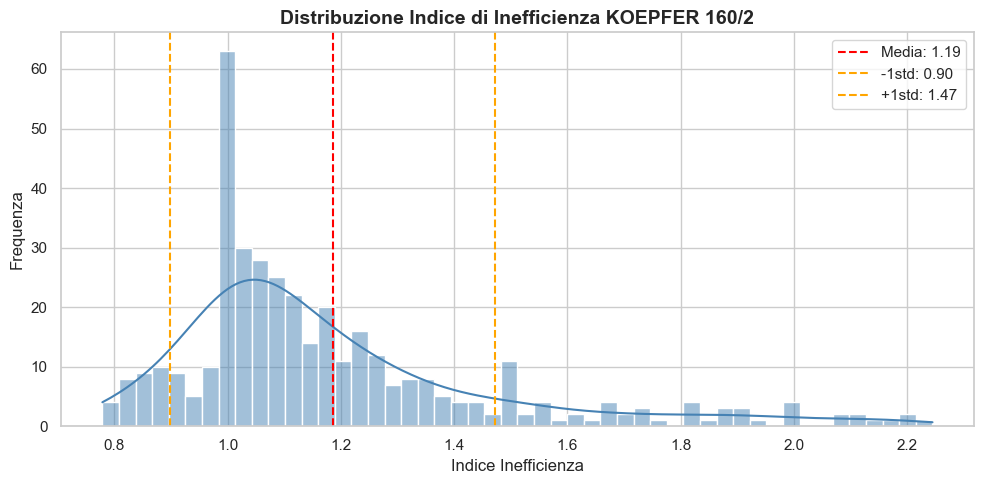

In [10]:
# Skewness
print("Skewness analysis:")
print(df_machine["Indice_Inefficienza"].skew(numeric_only=True))

# graph of the inefficient index on the choosen machine
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df_machine["Indice_Inefficienza"], bins=50, kde=True, color="steelblue", ax=ax)

media = df_machine["Indice_Inefficienza"].mean()
std = df_machine["Indice_Inefficienza"].std()

ax.set_title("Distribuzione Indice di Inefficienza KOEPFER 160/2", fontsize=14, fontweight="bold")
ax.set_xlabel("Indice Inefficienza")
ax.set_ylabel("Frequenza")
ax.axvline(media, color="red", linestyle="--", label=f"Media: {df_machine['Indice_Inefficienza'].mean():.2f}")
ax.axvline(media - std, color="orange", linestyle="--", linewidth=1.5, label=f"-1std: {media-std:.2f}")
ax.axvline(media + std, color="orange", linestyle="--", linewidth=1.5, label=f"+1std: {media+std:.2f}")
ax.legend()
plt.tight_layout()
plt.show()

# ****** APPUNTI ******
# la variabile dell'indice di inefficienza risulta avere una skewness elevata,
# ovvero la maggiorparte dei dati sono situati nella parte sinistra del grafo con
# una lunga coda a destra con pochi dati che sono gli outlier
# questo è tipico di dati di produzione che sono caratterizzati da pochi outlier elevati.
# ora nell'addestramento dei dati nei modelli lineari non faccio direttamente un log transform sui dati
# che converte dati con distribuzioni asimmetriche (come questi che abbiamo) in una scala logaritmica,
# rendendoli più simili a una distribuzione normale.
# ma uso inizialmente solo lo standard scaler sui dati 
# se i modelli lineari avranno performace negativa (molto probabile)
# allora provo a fare un log transform 